In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
symbol = 'AL'
train_label = 5
train_end_date = '2025-07-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'AL',
 'contract_multiplier': 5,
 'price_tick': 5,
 'margin_rate': 0.09,
 'fee': 3,
 'fee_way': 'number',
 'fee_comment': '无',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-01:00'],
 'light': 1,
 'night': 1,
 'exchange': 'shfe',
 'name': '铝'}

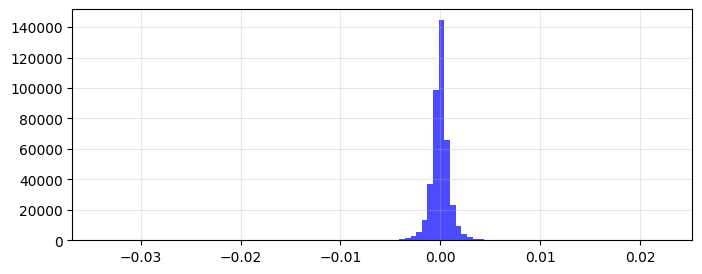


Fold 1/5
Fold 1 验证集日期范围: 2021-02-09 09:11:00 至 2021-12-28 23:13:00
Fold 1 训练集样本数: 332617, 验证集样本数: 83155
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.992374
[200]	valid_0's l2: 0.992237
[300]	valid_0's l2: 0.99225
[400]	valid_0's l2: 0.992174
[500]	valid_0's l2: 0.992149
[600]	valid_0's l2: 0.992232
[700]	valid_0's l2: 0.992306
[800]	valid_0's l2: 0.992467
[900]	valid_0's l2: 0.992603
Early stopping, best iteration is:
[465]	valid_0's l2: 0.992139


<Figure size 1000x600 with 0 Axes>

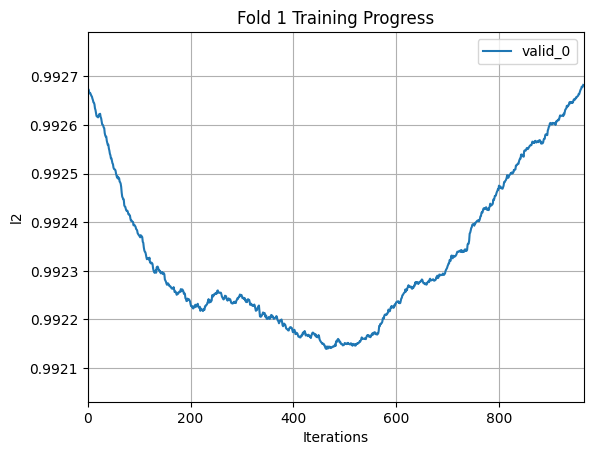

valid ic: 0.023448739411044615
模型最佳迭代次数 = 465

Fold 2/5
Fold 2 验证集日期范围: 2021-12-28 23:14:00 至 2022-11-15 09:15:00
Fold 2 训练集样本数: 332617, 验证集样本数: 83155
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.992173
[200]	valid_0's l2: 0.992127
[300]	valid_0's l2: 0.992165
[400]	valid_0's l2: 0.992237
[500]	valid_0's l2: 0.992418
[600]	valid_0's l2: 0.99261
[700]	valid_0's l2: 0.992882
Early stopping, best iteration is:
[238]	valid_0's l2: 0.992107


<Figure size 1000x600 with 0 Axes>

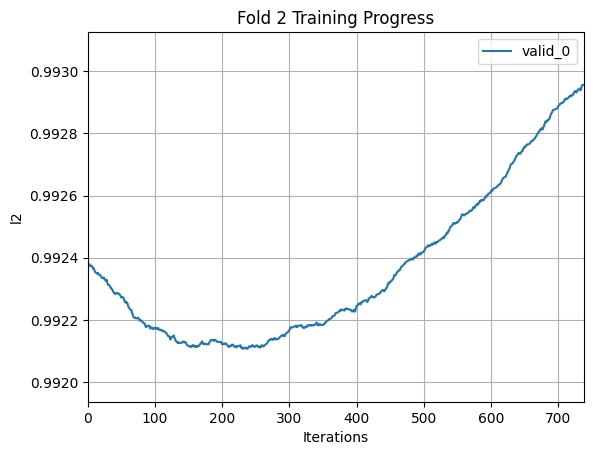

valid ic: 0.018562695460008338
模型最佳迭代次数 = 238

Fold 3/5
Fold 3 验证集日期范围: 2022-11-15 09:16:00 至 2023-09-22 09:12:00
Fold 3 训练集样本数: 332618, 验证集样本数: 83154
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.97768
[200]	valid_0's l2: 0.977579
[300]	valid_0's l2: 0.977539
[400]	valid_0's l2: 0.977506
[500]	valid_0's l2: 0.977477
[600]	valid_0's l2: 0.97746
[700]	valid_0's l2: 0.977442
[800]	valid_0's l2: 0.977424
[900]	valid_0's l2: 0.977432
[1000]	valid_0's l2: 0.977447
[1100]	valid_0's l2: 0.977464
[1200]	valid_0's l2: 0.977478
[1300]	valid_0's l2: 0.977494
Early stopping, best iteration is:
[822]	valid_0's l2: 0.977418


<Figure size 1000x600 with 0 Axes>

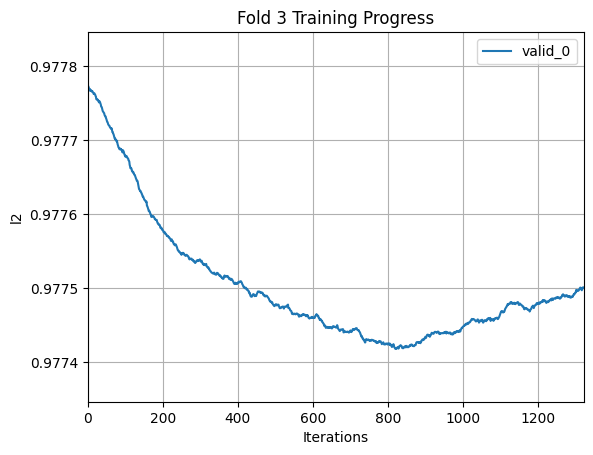

valid ic: 0.027925559363466492
模型最佳迭代次数 = 822

Fold 4/5
Fold 4 验证集日期范围: 2023-09-22 09:13:00 至 2024-08-09 09:42:00
Fold 4 训练集样本数: 332618, 验证集样本数: 83154
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.982185
[200]	valid_0's l2: 0.982109
[300]	valid_0's l2: 0.982047
[400]	valid_0's l2: 0.981993
[500]	valid_0's l2: 0.98197
[600]	valid_0's l2: 0.98193
[700]	valid_0's l2: 0.981912
[800]	valid_0's l2: 0.981888
[900]	valid_0's l2: 0.981886
[1000]	valid_0's l2: 0.981883
[1100]	valid_0's l2: 0.981891
[1200]	valid_0's l2: 0.981913
[1300]	valid_0's l2: 0.981906
Early stopping, best iteration is:
[881]	valid_0's l2: 0.981882


<Figure size 1000x600 with 0 Axes>

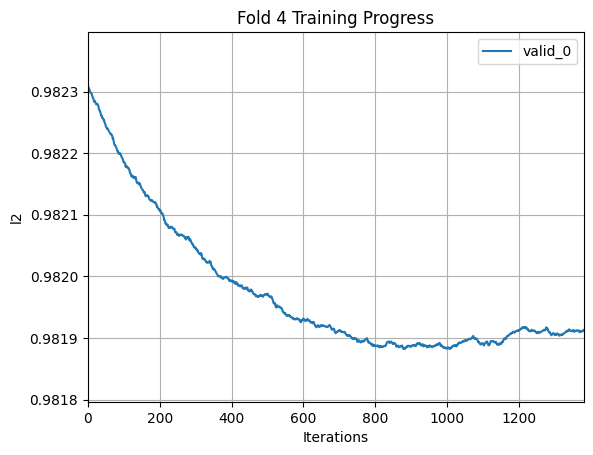

valid ic: 0.028693678532217194
模型最佳迭代次数 = 881

Fold 5/5
Fold 5 验证集日期范围: 2024-08-09 09:43:00 至 2025-07-01 23:59:00
Fold 5 训练集样本数: 332618, 验证集样本数: 83154
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.98875
[200]	valid_0's l2: 0.988757
[300]	valid_0's l2: 0.98879
[400]	valid_0's l2: 0.988832
[500]	valid_0's l2: 0.988884
[600]	valid_0's l2: 0.988938
Early stopping, best iteration is:
[157]	valid_0's l2: 0.988743


<Figure size 1000x600 with 0 Axes>

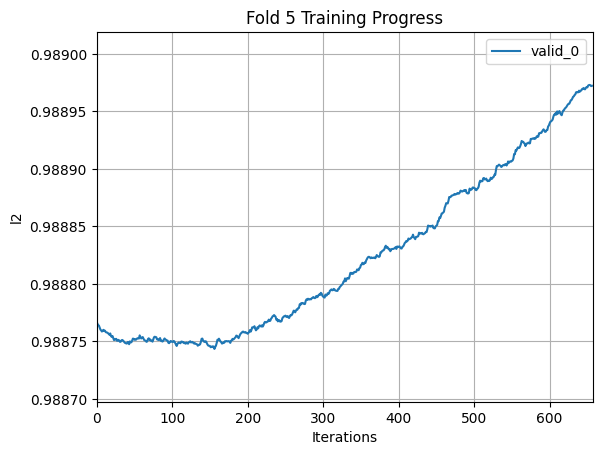

valid ic: 0.005347861748258055
模型最佳迭代次数 = 157
特征重要性已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/importance/2025-07-01_AL_5_feature_importance_reg.csv
特征相关系数表已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/correlation/2025-07-01_AL_5_feature_corr.csv
因子组别表已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/group/2025-07-01_AL_5_feature_group.csv
最后两列 Index(['pred_ret', 'hour'], dtype='object')


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [8]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_AL|_AO|_BC|_CU|_NI|_PB|_SN|_ZN|AL_|AO_|BC_|CU_|NI_|PB_|SN_|ZN_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['pred_ret']
特征分布性过滤：
筛选之前因子数量：1871， 筛选之后因子数量：1788

特征重要性过滤： 300 200 	待筛因子个数 1788
无向因子有效个数： 927 有向因子有效个数： 831
  选择有向特征 208 个，重要性范围: 536.00 - 11.00
  选择无向特征 130 个，重要性范围: 684.00 - 22.00

单因子sharpe过滤： 0.5 sp范围-6.9017 ~ 6.488   待筛因子个数 338

特征相关性性过滤： 300     待筛因子个数 277
  选择特征 229 个, 特征最大相关性0.8957172687077991

已挑选日频开盘因子数量： 5 ['day_first3power', 'day_jump', 'day_first4redcorr', 'day_first4greencorr', 'day_first10colarrate']

保留日频开盘因子数量： 5 ['day_first3power', 'day_jump', 'day_first4redcorr', 'day_first4greencorr', 'day_first10colarrate']

排除指定因子后，剩余特征 227 个


(162, 0, 38, 27)

In [10]:
lst3

['AL_PB_closepctchg20_sub',
 'AL_NI_closepctchg20_sub',
 'AL_ZN_closepctchg20_sub',
 'AL_SN_closepctchg20_sub',
 'AL_PB_closepctchg5_sub',
 'AL_ZN_closepctchg5_sub',
 'AL_NI_cvcorr10_diff',
 'AL_SN_closepctchg5_sub',
 'AL_CU_closepctchg20_sub',
 'AL_NI_closepctchg5_sub',
 'AL_ZN_cvcorr10_diff',
 'AL_CU_closepctchg5_sub',
 'AL_PB_cvcorr10_diff',
 'AL_AO_volumediv20_diff5',
 'AL_AO_cvcorr10_diff',
 'AL_AO_oi5_diff',
 'AL_AO_volumediv5_diff5',
 'AL_NI_oi5_diff',
 'AL_SN_oi5_diff',
 'AL_PB_oi5_diff',
 'AL_BC_oi5_diff',
 'AL_BC_vcorr10',
 'AL_BC_volumediv20_diff5',
 'AL_NI_volumediv20_diff5',
 'AL_BC_cvcorr10_diff',
 'AL_AO_closepctchg20_sub',
 'AL_SN_volumediv5_diff5',
 'AL_CU_volumediv20_diff5',
 'AL_AO_closepctchg5_sub',
 'AL_CU_volumediv5_diff5',
 'AL_ZN_oi5_diff',
 'AL_PB_volumediv20_diff5',
 'AL_NI_vcorr10',
 'AL_SN_volumediv20_diff5',
 'AL_CU_cvcorr10_diff',
 'AL_ZN_vcorr10',
 'AL_AO_vcorr10',
 'AL_PB_volumediv5_diff5']

正在从 /mnt/Data/writable/liaoyuyang/factor/AL/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (415371, 1875)
训练集时间范围: 2021-02-09 09:11:00 至 2025-07-01 00:00:00
[200]	valid_0's rmse: 0.995979
[400]	valid_0's rmse: 0.996105
[600]	valid_0's rmse: 0.996375


<Figure size 1000x600 with 0 Axes>

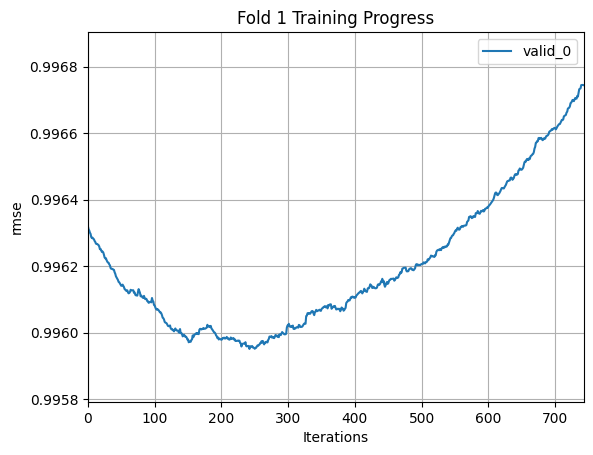

{'train_rmse': np.float64(0.9970569370818422), 'val_rmse': np.float64(0.9996211978234489), 'best_iteration': 243}
test_corr: 0.0082
[200]	valid_0's rmse: 0.995872
[400]	valid_0's rmse: 0.99608
[600]	valid_0's rmse: 0.996362


<Figure size 1000x600 with 0 Axes>

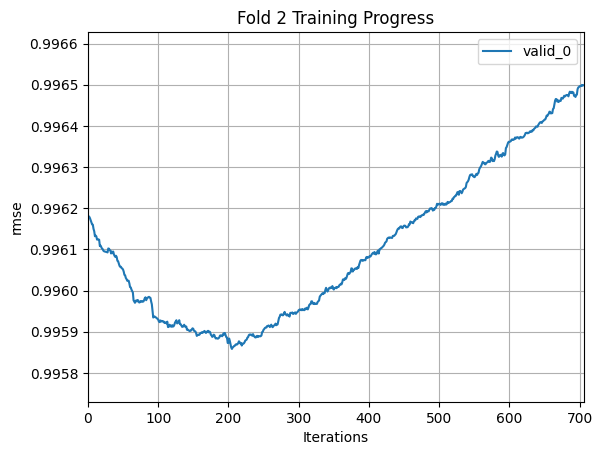

{'train_rmse': np.float64(0.9966305538679107), 'val_rmse': np.float64(0.9996202510508985), 'best_iteration': 206}
test_corr: 0.0278
[200]	valid_0's rmse: 0.988716
[400]	valid_0's rmse: 0.988684
[600]	valid_0's rmse: 0.9887
[800]	valid_0's rmse: 0.988715


<Figure size 1000x600 with 0 Axes>

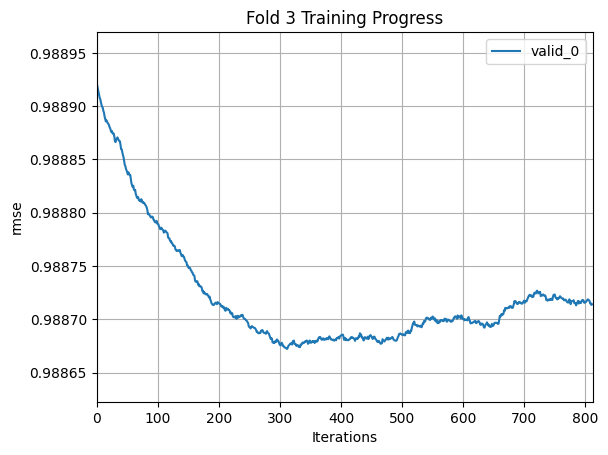

{'train_rmse': np.float64(0.9956336200915542), 'val_rmse': np.float64(0.999731403092273), 'best_iteration': 312}
test_corr: 0.0191
[200]	valid_0's rmse: 0.990977
[400]	valid_0's rmse: 0.990974
[600]	valid_0's rmse: 0.991015


<Figure size 1000x600 with 0 Axes>

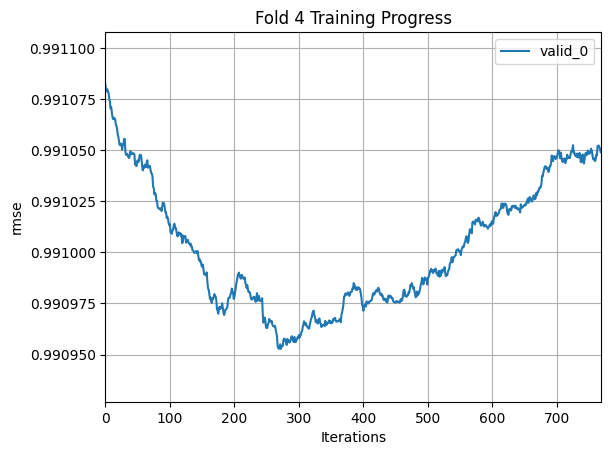

{'train_rmse': np.float64(0.9961135139357088), 'val_rmse': np.float64(0.9999416962304594), 'best_iteration': 269}
test_corr: 0.0217
[200]	valid_0's rmse: 0.994508
[400]	valid_0's rmse: 0.994668


<Figure size 1000x600 with 0 Axes>

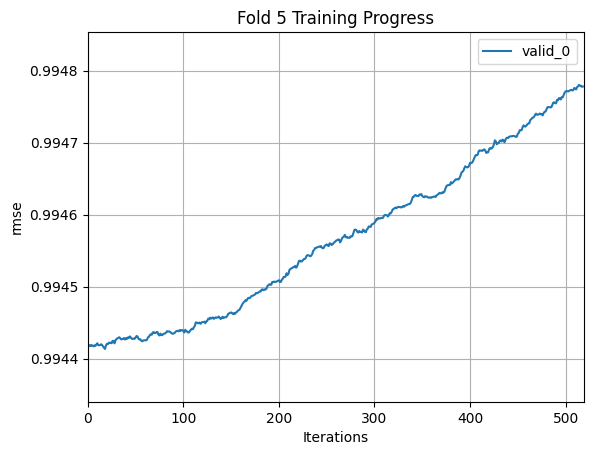

{'train_rmse': np.float64(0.9996275414786039), 'val_rmse': np.float64(1.000020533160641), 'best_iteration': 19}
test_corr: 0.0170


In [11]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [12]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/AL_pred5_2025-07-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [13]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 200_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [15]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*465, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-01:00']


  0%|          | 0/75525 [00:00<?, ?it/s]

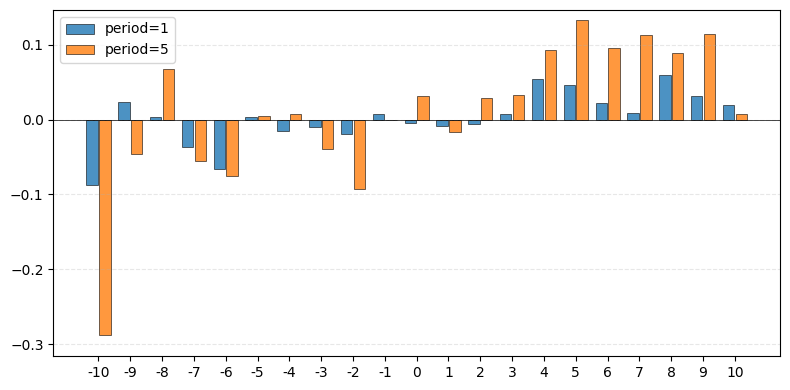

In [16]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-23:00"], g=21)

In [17]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,15034
空头(-1) 数量,14232
空仓(0) 数量,46261
多头占比,19.91%
空头占比,18.84%
空仓占比,61.25%
交易日数量,165
总收益(非年化%),99.90
总交易次数（开平算一次）,3571
每笔收益(%%),2.80


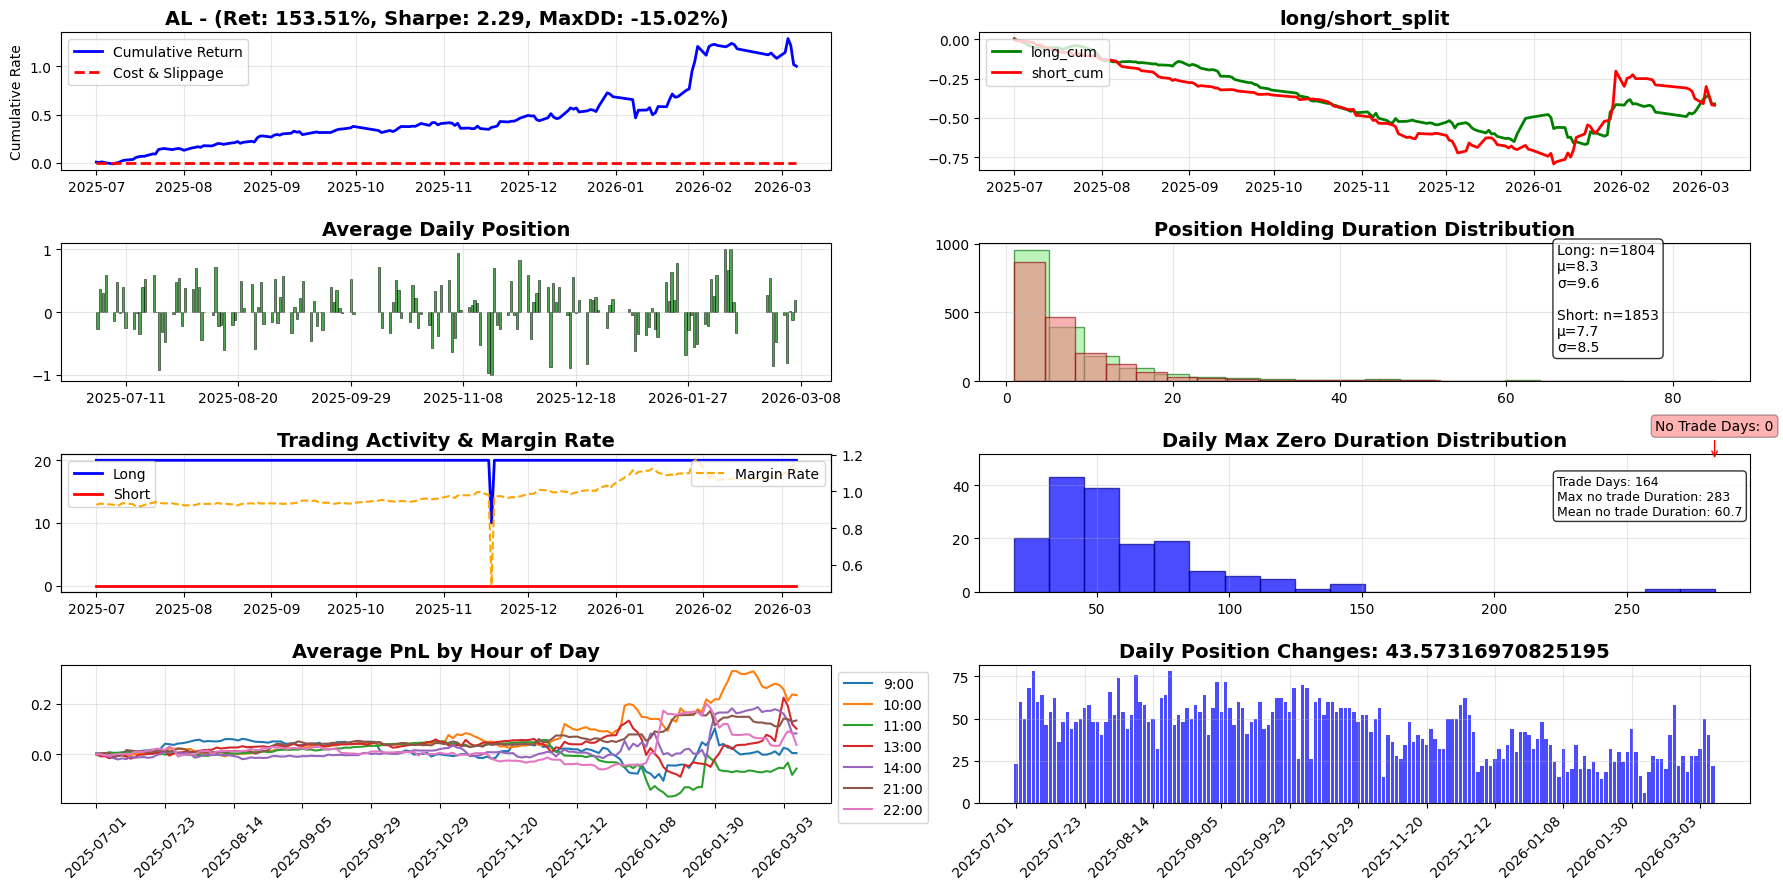

In [18]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [19]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

: 

: 

In [ ]:
bv.plot_yearly_eval(merged_data)